# Projeto de Concessão de Crédito - Data Girls Finance
**Autora:** Ana Livia da Costa Silva 
**Data:** Julho de 2026  

### Contexto de Negócio
Este projeto apresenta o desenvolvimento de um modelo preditivo de Machine Learning para classificação de Score de Crédito de clientes. O objetivo principal é automatizar a análise de risco, identificando padrões comportamentais e financeiros que otimizem a concessão de crédito de forma segura.

In [1]:
#bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
#leitura dos dados originais
df_raw = pd.read_csv('../data/raw/train.csv')
#visualizacao das 5 primeiras linhas
df_raw.head()

C:\Users\anali\AppData\Local\Temp\ipykernel_17416\1939724400.py:11: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('../data/raw/train.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 1. Leitura e Exploração Inicial dos Dados

Nesta etapa realizei a leitura inicial dos dados, extraindo a quantidade de registros, os tipos de variáveis e um resumo estatístico básico. Realizando então:
* Importação das bibliotecas essenciais para manipulação de dados 
* Carregamento do arquivo bruto 
* Remoção de colunas identificadoras 

**Por que isso foi feito:**
* Para observar os dados em seu estado original para mapear inconsistências.
* A exclusão de dados de identificação pessoal garante o cumprimento de normas éticas e de privacidade (como LGPD), além de evitar que o modelo tente aprender padrões baseados em nomes ou CPFs, o que não possui valor preditivo e gera ruído estatístico.


In [2]:
# numero de linhas e colunas
df_raw.shape

(100000, 28)

In [3]:
# tipo de dados e valores nao nulos
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  str    
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

In [4]:
# resumo da tabela
df_raw.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [5]:
# qntd total de valores nulos em cada coluna
df_raw.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

In [6]:
# qntd de linhas que sao iguais
df_raw.duplicated().sum()

np.int64(0)

## 2. Limpeza e Preparação dos Dados

Esta etapa traduz a base de dados para a linguagem das máquinas. Realizando então: 
* Higienização de strings, removendo caracteres indesejados das colunas financeiras e conversão para formatos numéricos.
* Divisão dos dados em conjuntos de Treino e Teste (`train_test_split`) com amostragem estratificada.

**Por que isso foi feito:**
* Modelos de Inteligência Artificial são baseados em matemática e não conseguem processar letras, caracteres especiais ou valores nulos.
* A separação em Treino e Teste antes da imputação garante que as métricas de limpeza sejam calculadas apenas com os dados de treino, simulando o cenário real de não possuirmos informações sobre os clientes do futuro.

In [7]:
# colunas irrelevantes para o modelo: identificadoras que não possuem nenhum poder de predição (LGPD: também removido por condutas éticas)
colunas_para_remover = ['ID', 'Customer_ID', 'Name', 'SSN']
df_clean = df_raw.drop(columns=colunas_para_remover)

# verificar a remocao
df_clean.shape

(100000, 24)

In [8]:
# identificar colunas q sejam texto para verificar se deveriam ser numericas
colunas_texto = df_clean.select_dtypes(include=['object']).columns
print(colunas_texto)

Index(['Month', 'Age', 'Occupation', 'Annual_Income', 'Num_of_Loan',
       'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score'],
      dtype='str')


C:\Users\anali\AppData\Local\Temp\ipykernel_17416\409889777.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df_clean.select_dtypes(include=['object']).columns


In [9]:
#as colunas encontradas deveriam ser numericas, logo o laço elimina ''_'' e espaços em brancos para ser reconhecidas como numericas
colunas_para_limpar = [
    'Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance'
]

# laço de repetição que realiza a limpezaa
for coluna in colunas_para_limpar:
    df_clean[coluna] = df_clean[coluna].astype(str).str.replace('_', '').str.strip()
    
   #transforma para numero decimal e oque for lixo vira nulo
    df_clean[coluna] = pd.to_numeric(df_clean[coluna], errors='coerce')

df_clean[colunas_para_limpar].info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  int64  
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  int64  
 3   Num_of_Delayed_Payment   92998 non-null   float64
 4   Changed_Credit_Limit     97909 non-null   float64
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  95521 non-null   float64
 7   Monthly_Balance          98800 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 6.1 MB


In [10]:
# separando em x e y antes das imputações
X = df_clean.drop(columns=['Credit_Score'])
y = df_clean['Credit_Score']

# mapeando os scores
score_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
y = y.map(score_mapping)

# separando em 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 3. Análise Exploratória (EDA): 
Nesta etapa eu analisei o que ocorre por trás dos padrões comportamentais dos clientes. Realizando então:

* Avaliação da distribuição da variável alvo `Credit_Score` para checar a proporção de cada classe.
* Construção de gráficos bivariados (boxplots e countplots agrupados) para cruzar o score de crédito com variáveis financeiras cruciais e variáveis comportamentais.

**Por que isso foi feito:**
* Identificar a predominância da classe "Standard" foi vital para tomarmos a decisão arquitetural de usar validação cruzada estratificada nas próximas etapas.
* Para provar estatisticamente que colunas como *Outstanding_Debt* realmente possuem peso matemático para separar um bom pagador de um mau pagador.
* Encontrar padrões visuais claros que respondam rapidamente às dúvidas da diretoria sobre o que mais impacta o risco de crédito, sem precisar de equações complexas.

C:\Users\anali\AppData\Local\Temp\ipykernel_17416\2198436333.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


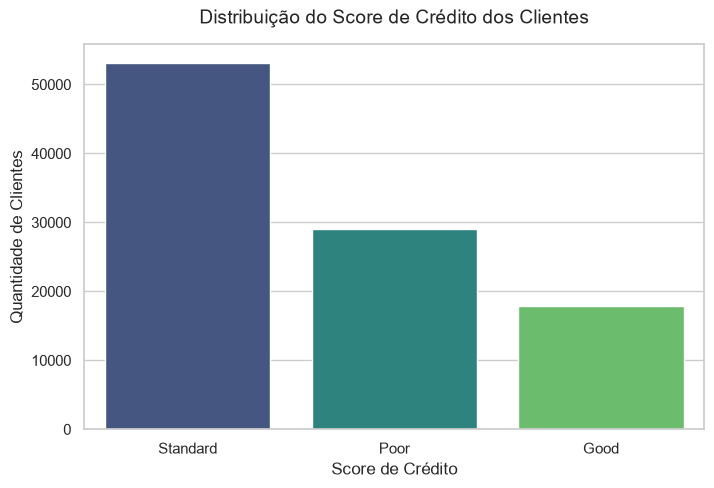

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
# cria o gráfico de barras para a  variável alvo
# parâmetro 'order' organiza as barras da maior para a menor
ax = sns.countplot(
    data=df_clean, 
    x='Credit_Score', 
    palette='viridis', 
    order=df_clean['Credit_Score'].value_counts().index
)

# storetelling
plt.title('Distribuição do Score de Crédito dos Clientes', fontsize=14, pad=15)
plt.xlabel('Score de Crédito', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

plt.show()

C:\Users\anali\AppData\Local\Temp\ipykernel_17416\3760546325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


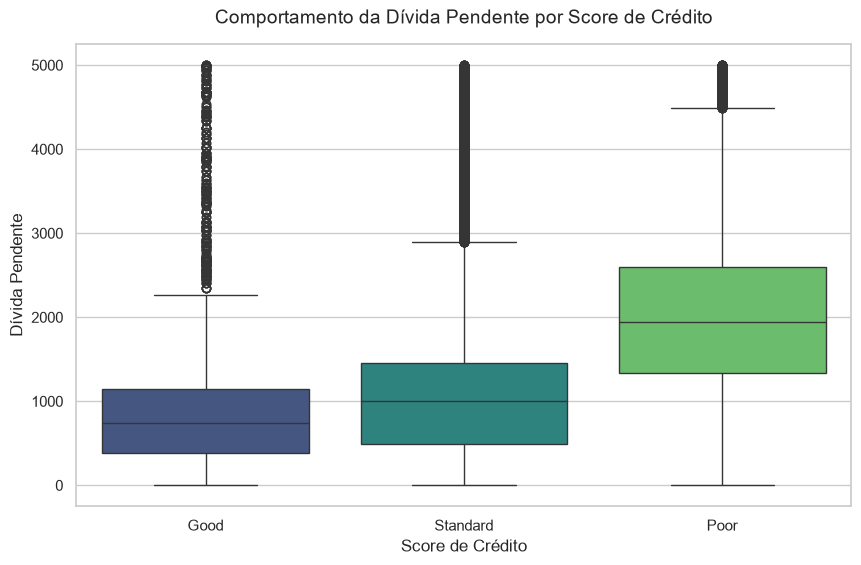

In [12]:

plt.figure(figsize=(10, 6))

# cria o gráfico cruzando o score (x) com a divida (y)
sns.boxplot(
    data=df_clean, 
    x='Credit_Score', 
    y='Outstanding_Debt', 
    palette='viridis',
    order=['Good', 'Standard', 'Poor'] #ordem do melhor para o pior score
)

plt.title('Comportamento da Dívida Pendente por Score de Crédito', fontsize=14, pad=15)
plt.xlabel('Score de Crédito', fontsize=12)
plt.ylabel('Dívida Pendente', fontsize=12)

plt.show()

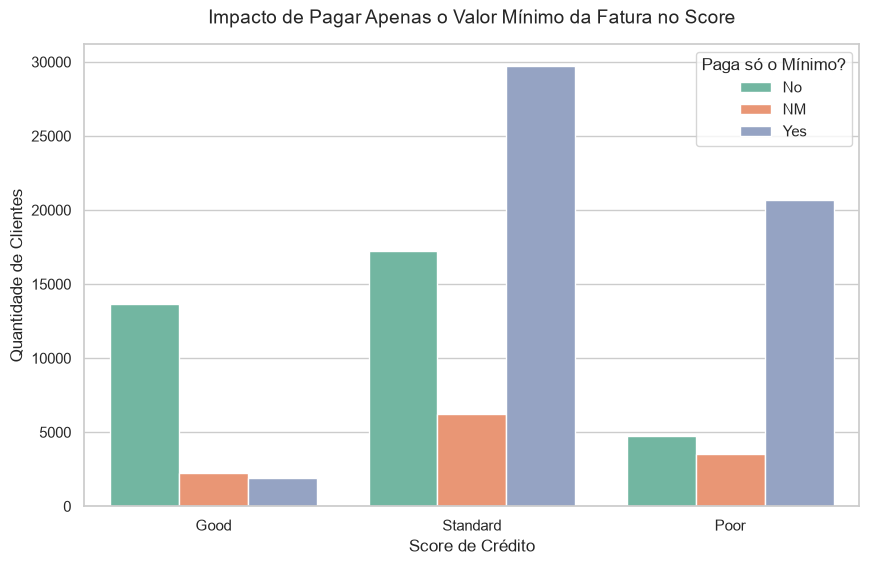

In [13]:
plt.figure(figsize=(10, 6))

# cria o grafico de barras  cruzando score e pagamento mínimo
ax = sns.countplot(
    data=df_clean, 
    x='Credit_Score', 
    hue='Payment_of_Min_Amount', 
    palette='Set2', 
    order=['Good', 'Standard', 'Poor']
)

# storytelling
plt.title('Impacto de Pagar Apenas o Valor Mínimo da Fatura no Score', fontsize=14, pad=15)
plt.xlabel('Score de Crédito', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

plt.legend(title='Paga só o Mínimo?', loc='upper right')

plt.show()

### Preparação de Dados e Engenharia de Features
Nesta etapa, estruturamos o processamento dos dados utilizando a ferramenta `Pipeline` do Scikit-Learn. Ela automatiza a sequência de limpeza e garante que as exatas mesmas regras aplicadas aos dados de treinamento sejam aplicadas de forma idêntica aos dados de teste e a futuros clientes. Isso elimina o risco de vazamento de dados e garante que o modelo esteja pronto para entrar em produção de forma segura.

As regras matemáticas inseridas neste código foram definidas com base nos resultados da nossa Análise Exploratória (EDA) prévia. Como os gráficos revelaram a presença de outliers nas variáveis financeiras, escolhi preencher os dados numéricos ausentes utilizando a mediana, que é uma medida estatística mais robusta e segura do que a média nesses casos. Para os dados em formato de texto, optei pela substituição pelo valor mais frequente, a moda.
* O uso do `Pipeline` encapsula as regras de pré-processamento. Se novos clientes entrarem no banco amanhã, a esteira aplicará a mesma limpeza automaticamente, garantindo estabilidade ao modelo em produção.


In [ ]:
# para preencher os espaços nulos é feita a separação das colunas numericas e de texto
colunas_num = X.select_dtypes(include=['int64', 'float64']).columns
colunas_cat = X.select_dtypes(include=['object']).columns

# calculo da mediana para as colunas numericas
pipeline_numerico = Pipeline(steps=[
    ('imputer_num', SimpleImputer(strategy='median'))
])

# sub-pipeline para textos, para calcular a moda e transformar em número
pipeline_categorico = Pipeline(steps=[
    ('imputer_cat', SimpleImputer(strategy='most_frequent')),
    ('encoder_cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# juntando os dois caminhos no transformador central de colunas
preprocessador = ColumnTransformer(transformers=[
    ('num', pipeline_numerico, colunas_num),
    ('cat', pipeline_categorico, colunas_cat)
])


C:\Users\anali\AppData\Local\Temp\ipykernel_17416\2319248817.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_cat = X.select_dtypes(include=['object']).columns


## 4. Modelagem Preditiva

Com os dados limpos e balanceados, iniciei a fase de construção e treinamento para classificar o score. Realizando então:
* Treinamento de dois algoritmos com naturezas matemáticas distintas: uma *baseline* linear (**Regressão Logística** com escalonamento de dados via `StandardScaler`) e um algoritmo não-linear avançado baseado em árvores de decisão (**Random Forest**).
* Realização de *Tuning* de hiperparâmetros (ajuste fino) no modelo vencedor através do `RandomizedSearchCV`, aplicando Validação Cruzada (Cross-Validation).

**Por que isso foi feito:**
* O teste de múltiplos modelos comprova qual arquitetura lida melhor com a complexidade do comportamento humano. A Regressão Logística assumiu que os dados eram lineares e falhou, enquanto a Floresta Aleatória capturou exceções complexas com excelência.
* O *Tuning* combinado com a Validação Cruzada limitou a profundidade das árvores, impedindo o modelo de "decorar" os dados de treino (*Overfitting*) e garantindo que sua alta performance se sustente com dados novos e desconhecidos.

In [ ]:

# primeiro modelo:RandomForestClassifier
pipeline_final_rf = Pipeline(steps=[
    ('preprocessor', preprocessador),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# o preprocessador aprende com o treino e aplica no teste automaticamente
print("Treinando o Pipeline com Random Forest (Sem vazamento de dados)...")
pipeline_final_rf.fit(X_train, y_train)

predicoes_rf = pipeline_final_rf.predict(X_test)
print(f"Acurácia do Pipeline Random Forest: {accuracy_score(y_test, predicoes_rf):.2%}")

Treinando o Pipeline com Random Forest (Sem vazamento de dados)...
Acurácia do Pipeline Random Forest: 78.75%


In [ ]:
#segundo modelo: regressao
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# inclusao do StandardScaler para nivelar as grandezas numericass
pipeline_numerico_lr = Pipeline(steps=[
    ('imputer_num', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])
preprocessador_lr = ColumnTransformer(transformers=[
    ('num', pipeline_numerico_lr, colunas_num),
    ('cat', pipeline_categorico, colunas_cat) 
])

# pre processamento escalonado + regressão logística
pipeline_final_lr = Pipeline(steps=[
    ('preprocessor', preprocessador_lr),
    ('model', LogisticRegression(max_iter=1000, random_state=42)) 
])

# treinamento
print("Treinando o segundo modelo: Regressão Logística...")
pipeline_final_lr.fit(X_train, y_train)

predicoes_lr = pipeline_final_lr.predict(X_test)
print(f"Acurácia da Regressão Logística: {accuracy_score(y_test, predicoes_lr):.2%}")

Treinando o segundo modelo: Regressão Logística...
Acurácia da Regressão Logística: 59.38%


c:\Users\anali\Projetos\Credito\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**A necessidade do StandardScaler**
Diferente da Floresta Aleatória, a Regressão Logística é uma equação matemática pura. Isso significa que ela sofre distorções se os dados tiverem grandezas muito diferentes (ex: uma idade de 30 anos vs. um salário de 10.000). O `StandardScaler` foi introduzido para nivelar todas as variáveis numéricas para a mesma escala proporcional, garantindo que o algoritmo não dê importância excessiva ao salário apenas por ser um número maior.

**Análise do Resultado e Aviso de Convergência (ConvergenceWarning):**
Durante o treinamento, o modelo emitiu um aviso informando que não conseguiu convergir mesmo após 1.000 tentativas. A acurácia final foi de apenas 59.38%.
* Insight: Isso comprova estatisticamente que o comportamento de crédito dos clientes da *Data Girls Finance* não é linear. Existem muitas variáveis, curvas e exceções no comportamento humano que uma simples linha reta (Regressão) não consegue separar.

### Tuning de Hiperparâmetros e Validação Cruzada

In [16]:
#aplicar validaçao cruzada e tuning no modelo Random Forest para extrair o máximo de performance dele
from sklearn.model_selection import RandomizedSearchCV

# definindo as configuracoes
param_grid = {
    'model__n_estimators': [100, 200],         
    'model__max_depth': [10, 20, None],        
    'model__min_samples_split': [2, 5, 10]     
}

# configuracao do randomizedsearch e validacao em 3 partes
otimizador = RandomizedSearchCV(
    estimator=pipeline_final_rf,
    param_distributions=param_grid,
    n_iter=5,          
    cv=3,              
    scoring='accuracy',
    random_state=42,
    n_jobs=-1          
)

# iniciando os ajustes finos 
print("Iniciando o Tuning e Validação Cruzada")
otimizador.fit(X_train, y_train)

# resultados
print(f"\nBusca concluída.")
print(otimizador.best_params_)

# avaliando o modelo otimizado nos dados de teste intocados
melhor_modelo_rf = otimizador.best_estimator_
predicoes_otimizadas = melhor_modelo_rf.predict(X_test)
nova_acuracia = accuracy_score(y_test, predicoes_otimizadas)

print(f"\nNova Acurácia do Random Forest Otimizado: {nova_acuracia:.2%}")

Iniciando o Tuning e Validação Cruzada

Busca concluída.
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__max_depth': 20}

Nova Acurácia do Random Forest Otimizado: 77.58%


### Comparação dos modelos com base em métricas de classificação.


In [24]:
#Comparando metricas de classificaçao Random Florest
from sklearn.metrics import classification_report

print("COMPARAÇÃO DE MÉTRICAS (Random Forest Otimizado)\n")
relatorio_metricas = classification_report(y_test, predicoes_otimizadas, target_names=['Poor', 'Standard', 'Good'])
print(relatorio_metricas)

COMPARAÇÃO DE MÉTRICAS (Random Forest Otimizado)

              precision    recall  f1-score   support

        Poor       0.78      0.77      0.78      5799
    Standard       0.80      0.80      0.80     10635
        Good       0.69      0.71      0.70      3566

    accuracy                           0.78     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.78      0.78      0.78     20000



In [22]:
#Comparando metricas de classificaçao Regressão
from sklearn.metrics import classification_report

print("COMPARAÇÃO DE MÉTRICAS (Regressão Logística)\n")
relatorio_metricas_lr = classification_report(y_test, predicoes_lr, target_names=['Poor', 'Standard', 'Good'])
print(relatorio_metricas_lr)

COMPARAÇÃO DE MÉTRICAS (Regressão Logística)

              precision    recall  f1-score   support

        Poor       0.62      0.42      0.50      5799
    Standard       0.60      0.79      0.68     10635
        Good       0.51      0.30      0.38      3566

    accuracy                           0.59     20000
   macro avg       0.58      0.50      0.52     20000
weighted avg       0.59      0.59      0.57     20000



# 5. Avaliação dos Modelos

Atingir uma alta taxa de acertos é fundamental, mas no setor financeiro, nem todo erro custa o mesmo valor. Aprovar crédito para um mau pagador gera prejuízo financeiro direto, enquanto negar crédito para um bom pagador gera perda de oportunidade de lucro com juros.

Nesta etapa, utilizamos a Matriz de Confusão  para investigar o comportamento do nosso modelo vencedor (Random Forest Otimizado) não apenas pelos seus acertos, mas pela natureza das suas falhas.

**Por que realizar essa análise visual?**
* Mapeamento de Falsos Positivos:Precisamos quantificar quantas vezes o modelo classificou acidentalmente um cliente com a realidade "Poor" (ruim) como "Good" (bom). Esse é o erro mais perigoso para o caixa da instituição.
* Mapeamento de Falsos Negativos: Identificar quantas vezes um cliente excelente ("Good") foi rotulado como ruim ("Poor"), levando a uma recusa injusta de crédito.
* Segurança para Produção: Ao expor visualmente onde o modelo "se confunde", provamos para a diretoria que a ferramenta construída é conservadora, previsível e segura para ser integrada à esteira de aprovação automática do banco.

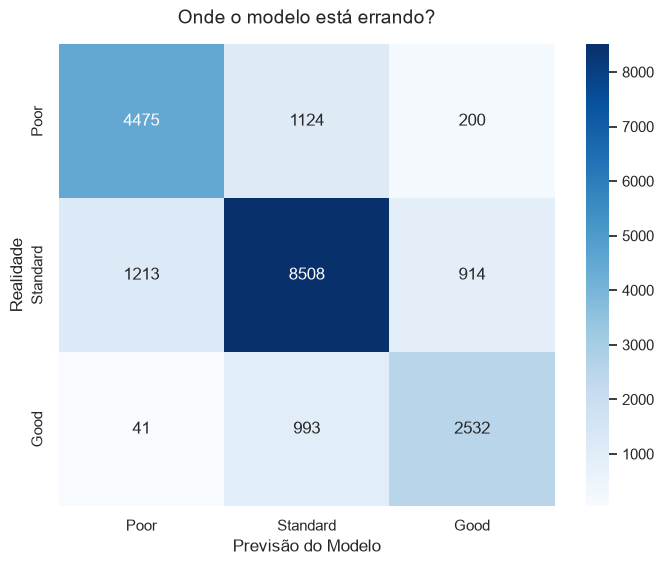

In [18]:
#investigando como e onde o modelo erra
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

#calcula a matriz de erro cruzando y_test com as previsões da floresta otimizada
matriz_confusao = confusion_matrix(y_test, predicoes_otimizadas)

# configuracoes do grafico 
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_confusao, 
    annot=True,          
    fmt='d',             
    cmap='Blues',        
    xticklabels=['Poor', 'Standard', 'Good'], 
    yticklabels=['Poor', 'Standard', 'Good']  
)

# textos explicativos para o storytelling
plt.title('Onde o modelo está errando?', fontsize=14, pad=15)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Realidade', fontsize=12)

plt.show()

# 6. Bônus: nterpretabilidade do Modelo-Lime!!!
Modelos baseados em dezenas de Árvores de Decisão tendem a entregar alta precisão, mas não conseguem explicar naturalmente o raciocínio matemático por trás daquela previsão. No setor de concessão de crédito, uma recusa sem justificativa fere os direitos do consumidor e as normas de compliance.

Para solucionar esse problema técnico e jurídico, implementamos a biblioteca **LIME (Local Interpretable Model-agnostic Explanations)**.

**O que foi feito:**
* Extraí o processador e o modelo treinado da nossa esteira de produção.
* Selecionei um cliente individual (Cliente nº 10 da base de teste) e o LIME desmonta a previsão matemática desse cliente específico.

**Como ler o resultado de negócio:**
* **Barras Vermelhas:** Demonstram as variáveis que estão "puxando" o score do cliente para baixo (ex: uma dívida pendente muito alta).
* **Barras Verdes:** Demonstram comportamentos positivos que seguraram o cliente e impediram que seu score despencasse para "Poor" (ex: o fato de ele não ter o hábito de pagar apenas o mínimo da fatura).

Com esta ferramenta, o banco possui um mecanismo rastreável, ético e seguro para justificar e auditar 100% das suas decisões automatizadas de crédito.

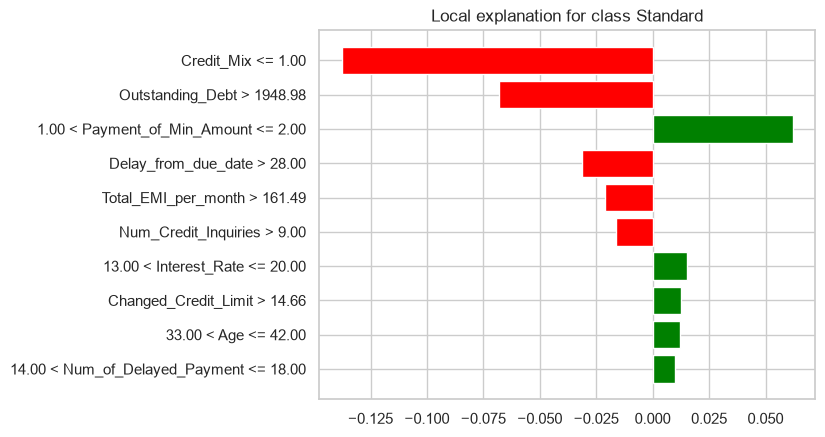

In [ ]:
#BONUS lime
import lime
import lime.lime_tabular

# extraindo as peças do pipeline: o modelo e o preparador
modelo_rf = melhor_modelo_rf.named_steps['model']
preprocessador = melhor_modelo_rf.named_steps['preprocessor']

# transformando os dados para o LIME entender 
X_train_transformado = preprocessador.transform(X_train)
X_test_transformado = preprocessador.transform(X_test)
nomes_todas_features = colunas_num.tolist() + colunas_cat.tolist()

# criando o Explicador LIME
# ele estuda o treinamento para entender como as variáveis se comportam
explicador = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformado,
    feature_names=nomes_todas_features,
    class_names=['Poor', 'Standard', 'Good'],
    mode='classification'
)

# escolhendo um cliente específico para investigar 
cliente_alvo = X_test_transformado[10]

# gerando a explicação: "Por que você deu essa nota para este cliente específico?"
explicacao = explicador.explain_instance(
    data_row=cliente_alvo, 
    predict_fn=modelo_rf.predict_proba
)

import matplotlib.pyplot as plt

# exibindo o relatório visual do LIME usando o Matplotlib puro!
figura = explicacao.as_pyplot_figure()
plt.show()